In [ ]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import os

# Load the CSV file containing image metadata
df = pd.read_csv('/kaggle/input/datasets/atharvadhupkar/coco-data2/filtered_coco_metadata.csv')
print(df.shape)
print(df.columns.tolist())

(329487, 20)
['name_bicycle', 'name_bus', 'name_car', 'name_person', 'name_truck', 'image_index', 'segmentation', 'area', 'image_id', 'bbox', 'category_id', 'id', 'supercategory', 'license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url']


In [ ]:
import ast, os, requests
from PIL import Image
from io import BytesIO
import numpy as np 

# Map one-hot labels to a single integer label
label_cols = ['name_bicycle', 'name_bus', 'name_car', 'name_person', 'name_truck']
df['label_idx'] = df[label_cols].values.argmax(axis=1)

# Parse the bbox column into separate columns
df['bbox_parsed'] = df['bbox'].apply(ast.literal_eval)
df['bbox_x'] = df['bbox_parsed'].apply(lambda b: b[0])
df['bbox_y'] = df['bbox_parsed'].apply(lambda b: b[1])
df['bbox_w'] = df['bbox_parsed'].apply(lambda b: b[2])
df['bbox_h'] = df['bbox_parsed'].apply(lambda b: b[3])

# Keep only relevant columns for training
bbox_df = df[['file_name', 'coco_url', 'image_id',
              'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'label_idx']].copy()

# Split by unique image_id to avoid leakage
unique_images = bbox_df['image_id'].unique()
rng = np.random.default_rng(42)
rng.shuffle(unique_images)

# Split into train/val/test
n = len(unique_images)
train_imgs = set(unique_images[:int(0.7 * n)])
val_imgs   = set(unique_images[int(0.7 * n):int(0.85 * n)])
test_imgs  = set(unique_images[int(0.85 * n):])

# Create pools for each split
train_pool = bbox_df[bbox_df['image_id'].isin(train_imgs)]
val_pool   = bbox_df[bbox_df['image_id'].isin(val_imgs)]
test_pool  = bbox_df[bbox_df['image_id'].isin(test_imgs)]

TRAIN_PER_CLASS = 1000
VAL_PER_CLASS   = 200
TEST_PER_CLASS  = 200

# Function to sample a fixed number of examples per class
def sample_per_class(pool, n_per_class):
    return (
        pool.groupby('label_idx')
            .apply(lambda x: x.sample(n=min(len(x), n_per_class), random_state=42),
                   include_groups=False)
            .reset_index(level=0) 
            .reset_index(drop=True)
    )

# Sample the final train/val/test sets
train_df = sample_per_class(train_pool, TRAIN_PER_CLASS)
val_df   = sample_per_class(val_pool,   VAL_PER_CLASS)
test_df  = sample_per_class(test_pool,  TEST_PER_CLASS)

print(f"Train size: {len(train_df)}, val size: {len(val_df)}, test size: {len(test_df)}, ")

# Download images for the sampled sets
os.makedirs('images', exist_ok=True)
needed_files = pd.concat([train_df, val_df, test_df])[['file_name', 'coco_url']].drop_duplicates()

FEATURE_FILE = "resnet50_avgpool_features.pkl"

if not os.path.exists(FEATURE_FILE):
    print("starting download")
    j = 0
    for i, (_, row) in enumerate(needed_files.iterrows()):
        if i % 1000 == 0:
            print(i)
        path = f"images/{row['file_name']}"
        if not os.path.exists(path):
            j+=1
            if j % 500 == 0:
                print(f"image {j}")
            resp = requests.get(row['coco_url'], timeout=10)
            Image.open(BytesIO(resp.content)).convert('RGB').save(path)
    
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print(f"Unique images to download: {len(needed_files)}")
    
    # Verify no leakage
    assert not (set(train_df['image_id']) & set(val_df['image_id'])), "Train/val image overlap"
    assert not (set(train_df['image_id']) & set(test_df['image_id'])), "Train/test image overlap"

Train size: 5000, val size: 1000, test size: 1000, 
starting download
0
image 500
image 1000
1000
image 1500
image 2000
2000
image 2500
image 3000
3000
image 3500
image 4000
4000
image 4500
image 5000
5000
image 5500
Train: 5000, Val: 1000, Test: 1000
Unique images to download: 5710


Data augmentation TODO in future done in the following block.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Define transformations for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Custom Dataset to load cropped images based on bounding boxes
class CocoCropDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"images/{row['file_name']}").convert('RGB')

        # Crop to bounding box
        x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
        img = img.crop((x, y, x + w, y + h))

        if self.transform:
            img = self.transform(img)

        return img, row['label_idx']

# Reset indexes cleanly before creating datasets
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Verify columns are present
print("Columns:", train_df.columns.tolist())
print("Sample row:", train_df.iloc[0])

# Create Datasets and DataLoaders
train_set = CocoCropDataset(train_df, transform)
val_set   = CocoCropDataset(val_df, transform)
test_set  = CocoCropDataset(test_df, transform)

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Columns: ['label_idx', 'file_name', 'coco_url', 'image_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']
Sample row: label_idx                                                    0
file_name                                     000000556149.jpg
coco_url     http://images.cocodataset.org/train2017/000000...
image_id                                                556149
bbox_x                                                  279.91
bbox_y                                                  144.43
bbox_w                                                   85.53
bbox_h                                                   54.43
Name: 0, dtype: object
Train: 5000, Val: 1000, Test: 1000


In [ ]:
from torchvision import models
import torch
import numpy as np
import joblib


# Use resnet as a feature extractor
extractor = models.resnet50(weights='IMAGENET1K_V1')
extractor = torch.nn.Sequential(*list(extractor.children())[:-1])
extractor.eval()

# Function to extract features from a DataLoader
def extract_features(loader):
    features, labels = [], []
    # Extract features in batches without computing gradients
    with torch.no_grad():
        for imgs, lbls in loader:
            feats = extractor(imgs).squeeze(-1).squeeze(-1)
            features.append(feats.numpy())
            labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)

FEATURE_FILE = "resnet50_avgpool_features.pkl"

# If cached features exist, load them. Otherwise, extract and save.
if os.path.exists(FEATURE_FILE):
    print("Loading cached features")
    X_train, X_val, X_test, y_train, y_val, y_test = joblib.load(FEATURE_FILE)
else:
    print("Extracting features")
    X_train, y_train = extract_features(train_loader)
    print("train extracted")
    X_val,   y_val   = extract_features(val_loader)
    print("val extracted")
    X_test,  y_test  = extract_features(test_loader)
    print("test extracted")
    joblib.dump((X_train, X_val, X_test, y_train, y_val, y_test), FEATURE_FILE)
    print("Features saved.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Extracting features
train extracted
val extracted
test extracted
Features saved.


In [ ]:
# Ran with GridSearch to find the best C.
# Experimental only, not required for final product.


# from sklearn.model_selection import GridSearchCV
# from sklearn.svm import LinearSVC
# from sklearn.metrics import classification_report

# grid = GridSearchCV(
#     LinearSVC(class_weight='balanced', max_iter=2000),
#     {'C': [0.01, 0.1, 1, 10]},
#     cv=3, scoring='f1_macro', verbose=1, n_jobs=-1
# )
# grid.fit(X_train, y_train)
# print("Best params:", grid.best_params_)
# print("Val:")
# print(classification_report(y_val, grid.predict(X_val)))
# print("Test (run once):")
# print(classification_report(y_test, grid.predict(X_test)))

Val (for tuning):
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       200
           1       0.79      0.82      0.81       200
           2       0.54      0.60      0.57       200
           3       0.81      0.83      0.82       200
           4       0.62      0.52      0.57       200

    accuracy                           0.72      1000
   macro avg       0.73      0.72      0.72      1000
weighted avg       0.73      0.72      0.72      1000

Test (final, run once)
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       200
           1       0.81      0.77      0.79       200
           2       0.64      0.62      0.63       200
           3       0.84      0.82      0.83       200
           4       0.61      0.64      0.62       200

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.75   

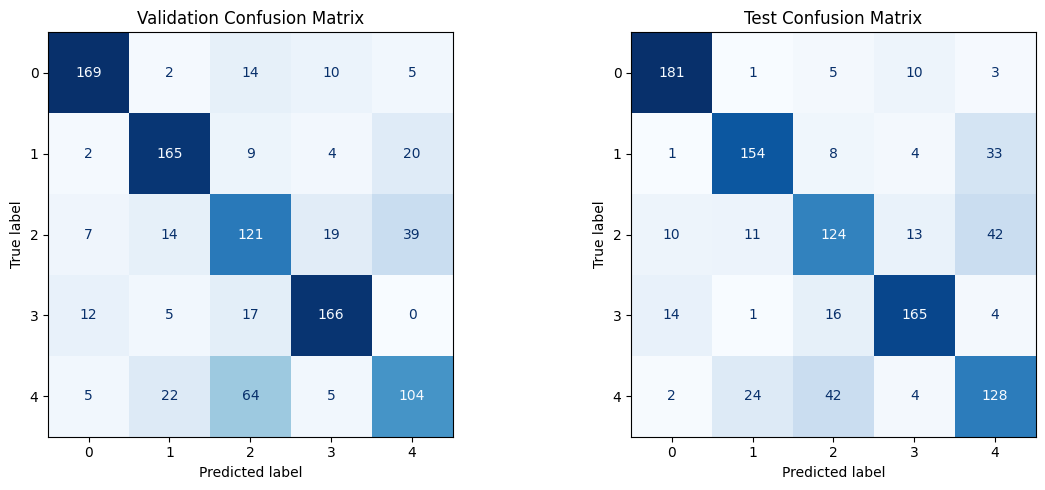

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
import torch

# Train the SVM with the best C found from GridSearch
svm = LinearSVC(C=1, class_weight='balanced', max_iter=2000)
svm.fit(X_train, y_train)

# Run model on validation set and print classification reports
print("Val (for tuning):")
print(classification_report(y_val, svm.predict(X_val)))

# Run model on test set and print classification reports
print("Test (final, run once)")
print(classification_report(y_test, svm.predict(X_test)))

# Visualize confusion matrices for val and test sets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (split_name, X, y) in zip(axes, [
    ("Validation", X_val, y_val),
    ("Test",       X_test, y_test)
]):
    cm = confusion_matrix(y, svm.predict(X))
    ConfusionMatrixDisplay(cm, display_labels=svm.classes_).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{split_name} Confusion Matrix")

plt.tight_layout()
plt.show()
